# Logreg-gated Range-Bound Short Straddle

Uses the multinomial logistic regression model from `regime_prediction_logreg.ipynb` as an entry/exit gate.

**Alpha signal:** at each decision tick, compute the 10 signed-distance features from the last 30 minutes of spot + ATM straddle, run `logreg.predict_proba`, and sum the probabilities of the two range_bound regimes (`range_bound x good_decay`, `range_bound x low_decay`).

**FSM:**
```
WAIT    --[range_bound_entry]--> SHORT     (P(range_bound) >= entry_prob)
SHORT   --[stop_hit]-----------> FLATTEN   priority 1 — loss >= stop_pct * credit
SHORT   --[target_hit]---------> FLATTEN   priority 2 — gain >= tp_pct  * credit
SHORT   --[regime_flip]--------> FLATTEN   priority 3 — P(range_bound) < exit_prob
SHORT   --[eod_squareoff]------> FLATTEN   priority 4 — near session end
SHORT   --[time_stop]----------> FLATTEN   priority 5 — max hold elapsed
FLATTEN --[always]-------------> WAIT
```

## 0. Load the trained logistic regression model\n\nRun section 10 of `regime_prediction_logreg.ipynb` first to generate the pickle.\nThis cell loads it — no retraining needed.

In [1]:
import sys, os, pickle, pathlib
import numpy as np, pandas as pd

_HERE      = os.path.abspath(".")
REGIME_DIR = os.path.join(_HERE, "..", "Regime_Classifier", "Regime_Classifier")
PRED_DIR   = os.path.join(_HERE, "..", "Regime_Predictor",  "Regime_Predictor")
for _p in (REGIME_DIR, PRED_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import regime_classifier as rc
import regime_config     as rcfg
from regime_classifier_model import model_spy2 as REGIME_CONFIG
from logreg_predictor import LogRegPredictor   # must be imported BEFORE pickle.load

# load the fitted model saved from regime_prediction_logreg.ipynb § 10
MODEL_PATH = pathlib.Path(_HERE) / "models" / "logreg_spy.pkl"
with open(MODEL_PATH, "rb") as f:
    payload = pickle.load(f)

logreg       = payload["logreg"]
REGIMES      = payload["REGIMES"]
FEATURE_COLS = payload["FEATURE_COLS"]
FWD_MIN      = payload["FWD_MIN"]

rc.SESSION = rcfg.session_dict("SPY")

print(f"loaded  {MODEL_PATH}")
print(f"  type     : {type(logreg).__name__}")
print(f"  C        : {logreg.C}")
print(f"  horizons : {FWD_MIN}")
print(f"  features : {FEATURE_COLS}")

loaded  /home/krishna/Project/BirdsEye/models/logreg_spy.pkl
  type     : LogRegPredictor
  C        : 0.03
  horizons : (15, 20, 25, 30)
  features : ['cur_slope_gap', 'cur_slope_sign', 'cur_er_gap', 'cur_range_gap', 'cur_decay_gap', 'prv_slope_gap', 'prv_slope_sign', 'prv_er_gap', 'prv_range_gap', 'prv_decay_gap']


## 1. Run the strategy

In [2]:
from engine import BirdsEye
from strategies.logreg_range_straddle import LogRegRangeStraddle

be = BirdsEye(
    strategy_cls    = LogRegRangeStraddle,
    index           = "SPY",
    split           = "train",
    strategy_kwargs = {
        "logreg"         : logreg,
        "regime_config"  : REGIME_CONFIG,
        "index"          : "SPY",
        "lots"           : 20,
        "entry_prob"     : 0.45,   # enter when P(range_bound) >= 0.45
        "exit_prob"      : 0.30,   # regime_flip exit when P(range_bound) < 0.30
        "pred_horizon"   : 20,     # 20-min ahead prediction
        "decision_every" : 60,     # recheck model every 60 s (= training step)
        "stop_pct"       : 1.0,    # stop when loss >= 1× credit
        "tp_pct"         : 0.50,   # take when gain >= 0.5× credit
        "hold_max"       : 3600,   # time-stop after 60 min
        "min_flat_sec"   : 900,    # 15-min cooldown after any exit before re-entry
        "min_hold_sec"   : 900,    # must hold 15 min before regime_flip can fire
        "eod_buffer"     : 600,    # close when <= 10 min remain in the day
    },
    cost_kwargs   = {"txn_cost_per_lot": 0.85},
    lot_size      = 100,
    starting_cash = 1_000_000.0,
    n_workers     = 10,
    # days=["20240102", "20240104"],   # uncomment for a quick 2-day smoke test
)
res = be.run()
print("Done")

[birdseye] log -> /home/krishna/Project/BirdsEye/logs/SPY_train_20260615_205818.log
Done


## 2. Per-day summary & aggregate stats

In [3]:
import pandas as pd
pd.set_option("display.max_rows", 60)

print("=== per-day summary ===")
display(res.summary)

print("\n=== aggregate stats ===")
for k, v in res.stats().items():
    print(f"  {k:<18}: {v}")

=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,64,630.0,497.0,133.0
20240104,64,500.0,462.0,38.0
20240105,64,-665.0,522.0,-1187.0
20240109,64,-312.5,484.5,-797.0
20240110,64,737.5,454.5,283.0
...,...,...,...,...
20250804,64,1387.5,449.5,938.0
20250806,64,-1802.5,489.5,-2292.0
20250807,64,1717.5,494.5,1223.0



=== aggregate stats ===
  n_days            : 277
  total_pnl         : -43970.0
  avg_day           : -158.74
  pct_pos_days      : 0.49
  pct_neg_days      : 0.48
  avg_win           : 741.99
  avg_loss          : -1086.73
  best_day          : 3243.0
  worst_day         : -5112.0
  win_rate          : 0.49
  cagr              : -0.04
  calmar            : -0.88
  maxDD_pct         : -0.04
  churn_per_day     : 0.03
  daily_maxDD       : -45405.0
  intraday_maxDD    : -8647.0
  total_costs       : 132892.5
  n_fills           : 16480


## 3. Tearsheet

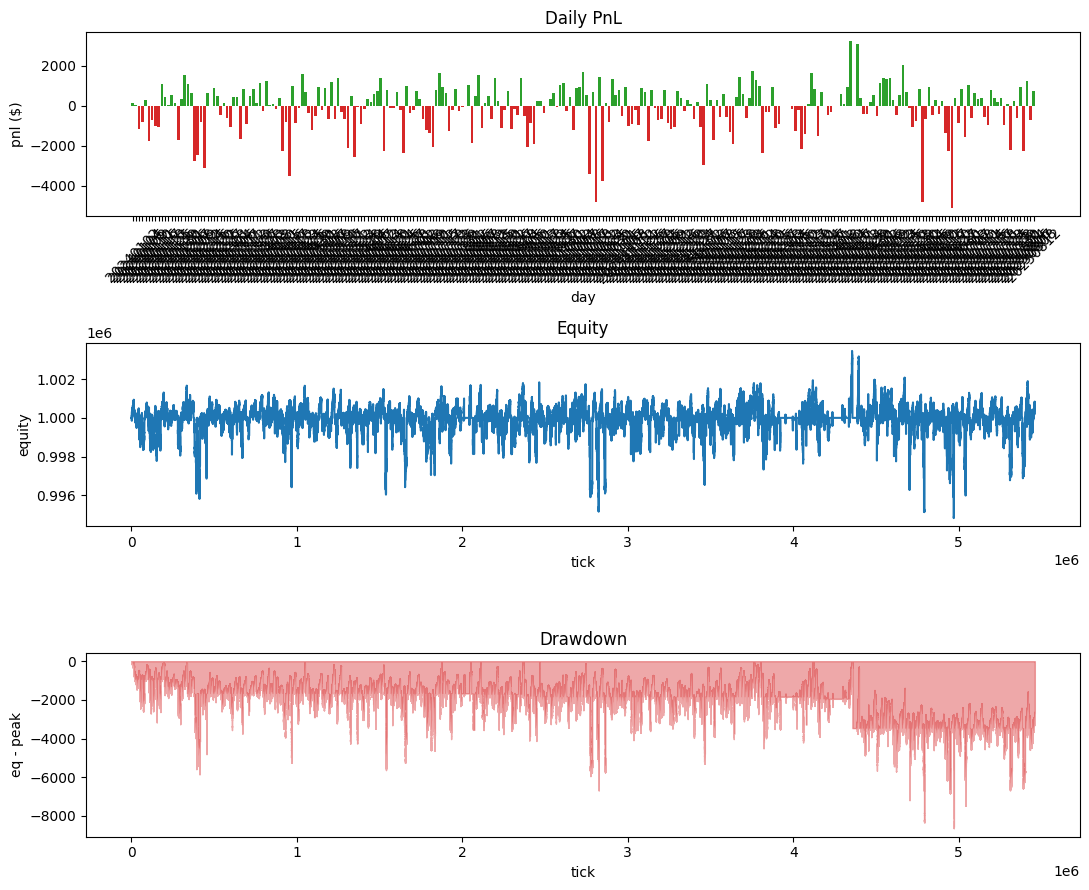

In [4]:
import matplotlib.pyplot as plt
res.tearsheet()
plt.show()

## 4. Trade ledger — exits by signal

In [5]:
led = res.Tradelog()
print(f"{len(led)} total fills across {len(res.days)} days\n")

EXIT_SIGNALS = ["stop_hit", "target_hit", "regime_flip", "eod_squareoff", "time_stop"]
exits = led[led["signal"].isin(EXIT_SIGNALS)]

print("=== exit fills by signal ===")
display(
    exits.groupby("signal")["exe_cost"]
         .agg(count="count", total_cost="sum")
         .round(2)
)

# alpha_range_prob at entry and exit — what P(range_bound) looked like when each signal fired
if "alpha_range_prob" in led.columns:
    print("\n=== P(range_bound) at fire time by signal ===")
    display(
        exits.groupby("signal")["alpha_range_prob"]
             .agg(["mean", "min", "max"])
             .round(3)
    )

print("\n=== all fills ===")
display(led.head(14))

16480 total fills across 277 days

=== exit fills by signal ===


,count,total_cost
signal,,
eod_squareoff,1808,14516.5
regime_flip,1288,11784.0
stop_hit,64,1019.5
time_stop,5080,45630.0



=== P(range_bound) at fire time by signal ===


,mean,min,max
signal,,,
eod_squareoff,0.819,0.06,0.97
regime_flip,0.239,0.01,0.30
stop_hit,0.578,0.39,0.82
time_stop,0.844,0.32,0.98



=== all fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,signal,note,alpha_sec,alpha_secs_remaining,alpha_spot,alpha_atm,alpha_range_prob,alpha_open_pnl,alpha_entry_credit,alpha_decision_now
0,20240102,3601,472.0,CE,SELL,5,0.69,4.25,0.0,5.0,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
1,20240102,3601,472.0,PE,SELL,5,0.92,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
2,20240102,3604,472.0,CE,SELL,5,0.68,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
3,20240102,3604,472.0,PE,SELL,5,0.94,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
4,20240102,3607,472.0,CE,SELL,5,0.68,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
5,20240102,3607,472.0,PE,SELL,5,0.94,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
6,20240102,3610,472.0,CE,SELL,5,0.66,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
7,20240102,3610,472.0,PE,SELL,5,0.94,4.25,0.0,2.5,...,range_bound_entry,range_prob=0.64,3600,16201,471.76,472.0,0.64,0.0,0.0,1
8,20240102,7201,472.0,CE,BUY,5,0.82,4.25,0.0,2.5,...,time_stop,square off,7200,12601,472.29,472.0,0.85,527.5,3227.5,1
9,20240102,7201,472.0,PE,BUY,5,0.53,4.25,0.0,5.0,...,time_stop,square off,7200,12601,472.29,472.0,0.85,527.5,3227.5,1


## 5. Per-second log — regime signal & state timeline

per-second log 20240102: 19721 rows
columns: ['timestamp', 'spot', 'atm', 'state', 'sec', 'secs_remaining', 'range_prob', 'open_pnl', 'entry_credit', 'decision_now']

=== state transitions ===


,timestamp,state,range_prob,open_pnl
0,0,WAIT,NaN,NaN
3601,3611,SHORT,0.64,-12.5
7191,7211,FLATTEN,0.85,0.0
7192,7212,WAIT,0.85,0.0
8081,8111,SHORT,0.94,10.0
11671,11711,FLATTEN,0.89,0.0
11672,11712,WAIT,0.89,0.0
12561,12611,SHORT,0.87,5.0
16151,16211,FLATTEN,0.80,0.0
16152,16212,WAIT,0.80,0.0



=== state occupancy (seconds) ===


state
SHORT      12861
WAIT        6856
FLATTEN        4
Name: count, dtype: int64

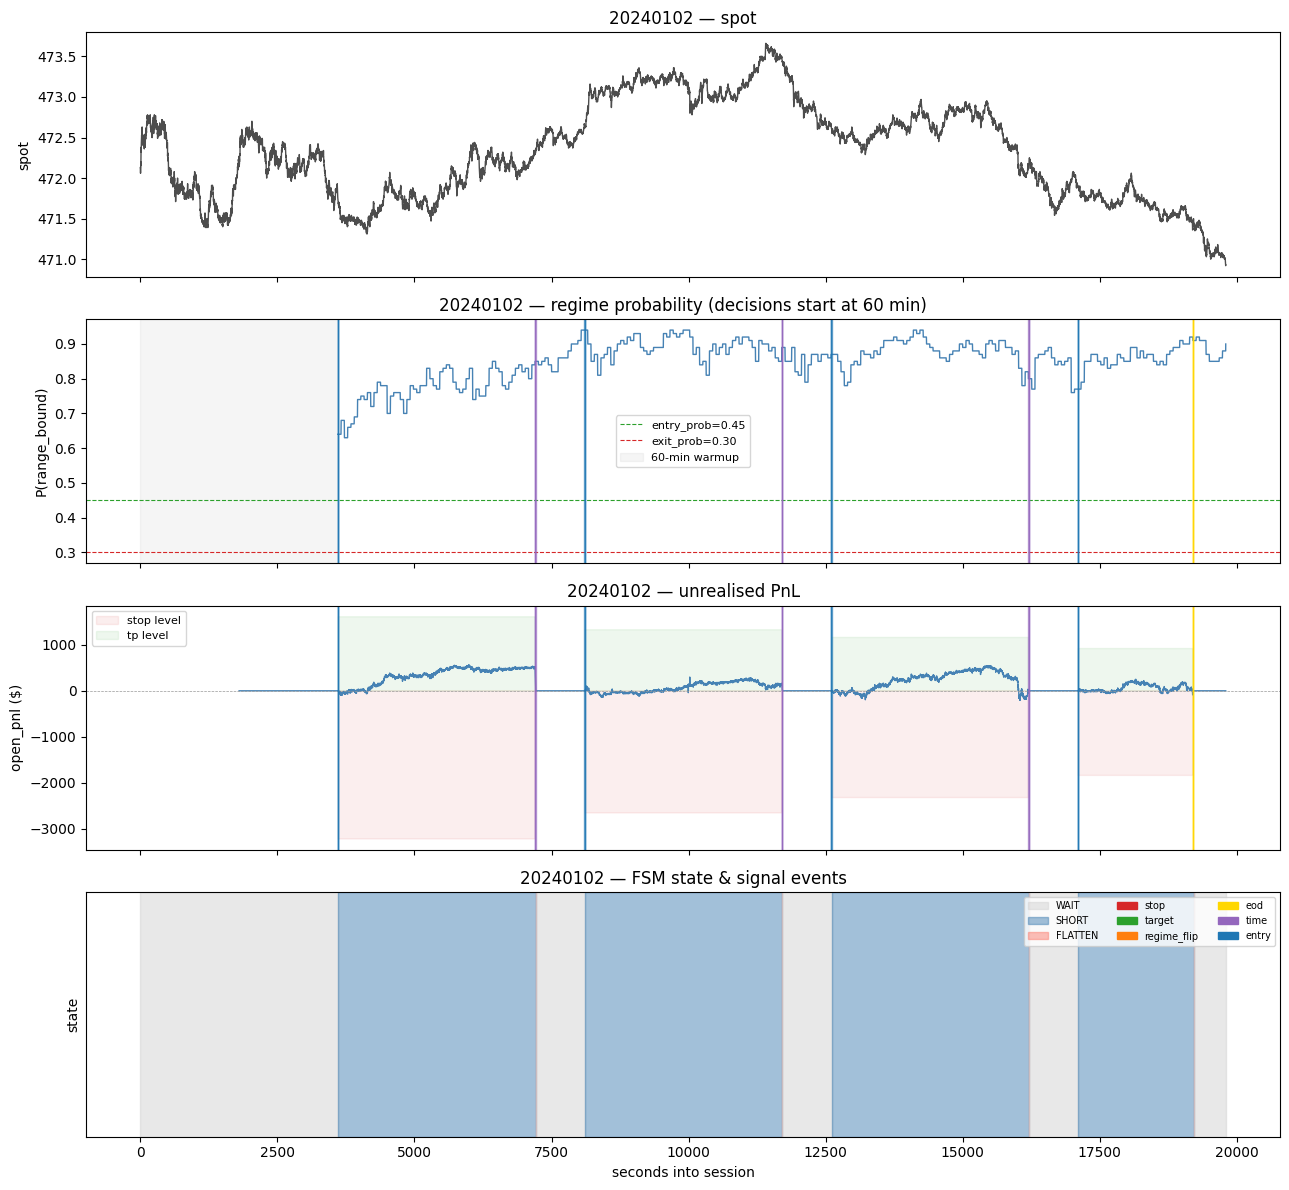

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DAY     = res.days[0]    # change to any date in res.days
sl      = res.perseclog(DAY)
day_led = res.Tradelog()
day_led = day_led[day_led["day"] == DAY].copy()

print(f"per-second log {DAY}: {len(sl)} rows")
print(f"columns: {list(sl.columns)}\n")

print("=== state transitions ===")
chg_cols = ["timestamp", "state"] + [c for c in ["range_prob", "open_pnl"] if c in sl.columns]
display(sl[sl["state"] != sl["state"].shift()][chg_cols])

print("\n=== state occupancy (seconds) ===")
display(sl["state"].value_counts())

# ---- timestamp: snap.ts is a row index (0-based integer seconds), NOT nanoseconds ----
ts0    = sl["timestamp"].iloc[0]
sl_sec = (sl["timestamp"] - ts0).values.astype(float)   # seconds since session open

EXIT_SIGNALS = ["stop_hit", "target_hit", "regime_flip", "eod_squareoff", "time_stop"]
COLORS = {
    "stop_hit":          ("tab:red",    "stop"),
    "target_hit":        ("tab:green",  "target"),
    "regime_flip":       ("tab:orange", "regime_flip"),
    "eod_squareoff":     ("gold",       "eod"),
    "time_stop":         ("tab:purple", "time"),
    "range_bound_entry": ("tab:blue",   "entry"),
}
sig_events = (
    day_led[day_led["signal"].isin(list(COLORS))]
    .drop_duplicates(subset=["timestamp", "signal"])
)

# Effective warmup = 2 * HIST_SEC (60 min):
#   First 30 min fills the buffer (no prediction possible).
#   Next 30 min: buffer still contains the trending morning open, so the
#   feature windows see high slope/ER → model predicts near-zero range_bound.
#   Decisions are deferred to 2*HIST_SEC=3600s to avoid this misleading period.
WARMUP_SEC = 2 * 1800

n_panels = 2 + ("range_prob" in sl.columns) + ("open_pnl" in sl.columns)
fig, axes = plt.subplots(n_panels, 1, figsize=(13, 3 * n_panels), sharex=True)
ax = iter(axes)

# panel: spot
a = next(ax)
a.plot(sl_sec, sl["spot"], lw=1, color="0.3")
a.set_ylabel("spot"); a.set_title(f"{DAY} — spot")

# panel: P(range_bound)
if "range_prob" in sl.columns:
    a = next(ax)
    rp = sl["range_prob"].copy().astype(float)
    rp[sl_sec < WARMUP_SEC] = float("nan")   # blank warmup so it's not mistaken for signal
    a.plot(sl_sec, rp, lw=1, color="steelblue")
    a.axhline(0.45, color="tab:green", lw=0.8, ls="--", label="entry_prob=0.45")
    a.axhline(0.30, color="tab:red",   lw=0.8, ls="--", label="exit_prob=0.30")
    a.axvspan(sl_sec[0], WARMUP_SEC, alpha=0.08, color="grey", label="60-min warmup")
    for _, row in sig_events.iterrows():
        col, _ = COLORS.get(row["signal"], ("grey", ""))
        a.axvline(float(row["timestamp"] - ts0), color=col, lw=1, alpha=0.6)
    a.set_ylabel("P(range_bound)"); a.legend(fontsize=8)
    a.set_title(f"{DAY} — regime probability (decisions start at 60 min)")

# panel: open_pnl with credit bands
if "open_pnl" in sl.columns:
    a = next(ax)
    a.plot(sl_sec, sl["open_pnl"], lw=1, color="steelblue")
    a.axhline(0, color="0.6", lw=0.5, ls="--")
    if "entry_credit" in sl.columns:
        short_mask = sl["state"] == "SHORT"
        cr = sl["entry_credit"].where(short_mask)
        a.fill_between(sl_sec, -cr,       0,     alpha=0.08, color="tab:red",   label="stop level")
        a.fill_between(sl_sec,  0,   cr * 0.5,   alpha=0.08, color="tab:green", label="tp level")
    for _, row in sig_events.iterrows():
        col, _ = COLORS.get(row["signal"], ("grey", ""))
        a.axvline(float(row["timestamp"] - ts0), color=col, lw=1, alpha=0.6)
    a.set_ylabel("open_pnl ($)"); a.legend(fontsize=8)
    a.set_title(f"{DAY} — unrealised PnL")

# panel: FSM state timeline
a = next(ax)
state_pal = {"WAIT": "lightgrey", "SHORT": "steelblue", "FLATTEN": "salmon"}
prev_s, prev_x = sl["state"].iloc[0], sl_sec[0]
for i in range(1, len(sl)):
    if sl["state"].iloc[i] != prev_s or i == len(sl) - 1:
        a.axvspan(prev_x, sl_sec[i], alpha=0.5, color=state_pal.get(prev_s, "white"))
        prev_s, prev_x = sl["state"].iloc[i], sl_sec[i]
patches     = [mpatches.Patch(color=c, alpha=0.5, label=s) for s, c in state_pal.items()]
sig_patches = [mpatches.Patch(color=c, label=l) for _, (c, l) in COLORS.items()]
a.legend(handles=patches + sig_patches, fontsize=7, ncol=3, loc="upper right")
a.set_ylabel("state"); a.set_xlabel("seconds into session")
a.set_title(f"{DAY} — FSM state & signal events"); a.set_yticks([])

plt.tight_layout()
plt.show()